# 202302904 선태욱 Problem4

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## InventoryEnv

In [2]:
class InventoryEnv:
    def __init__(self, T=100, I_max=50, Q_max=25, K=100, C=3, H=5, P=20, L=15):
        self.T = T
        self.I_max = I_max
        self.Q_max = Q_max
        self.K = K
        self.C = C
        self.H = H
        self.P = P
        self.L = L

        self.state_dim = 2
        self.terminal_states = [(self.T, I) for I in range(self.I_max + 1)]
        self.action_dim = self.Q_max + 1

    def reset(self):
        self.state = (0, 0)
        return np.array(self.state, dtype=np.float32)

    def step(self, action):
        t, I = self.state
        q = min(action, self.I_max - I)
        I_opening = I + q
        D = np.random.poisson(self.L)
        lost_sales = max(D - I_opening, 0)
        I_closing = max(I_opening - D, 0)

        order_cost = (self.K + self.C * q) if q > 0 else 0
        holding_cost = self.H * I_closing
        penalty_cost = self.P * lost_sales
        reward = -(order_cost + holding_cost + penalty_cost)

        self.state = (t + 1, I_closing)
        done = self.state in self.terminal_states

        return np.array(self.state, dtype=np.float32), reward, done

## (a) Actor Network

- Hidden layers: 1
- Hidden nodes: 128
- Activation: ReLU
- Output: logits → Categorical distribution
- Optimizer: Adam, lr=0.001

In [3]:
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        return self.net(state)  # logits

## (a) Critic Network

- Hidden layers: 1
- Hidden nodes: 128
- Activation: ReLU
- Output: scalar V(s)
- Optimizer: Adam, lr=0.001

In [4]:
class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state)  # scalar V(s)

## (b) Actor-Critic Learning Module (TD error as Advantage)

In [5]:
class ActorCritic_Learning:
    """
    0. Initialization
    """
    def __init__(self, state_dim, action_dim, gamma=0.99, actor_alpha=0.001, critic_alpha=0.001):
        self.state_dim = state_dim
        self.action_dim = action_dim

        self.actor = ActorNetwork(state_dim, action_dim).to(device)
        self.critic = CriticNetwork(state_dim).to(device)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_alpha)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_alpha)

        self.gamma = gamma

    """
    1. Stochastic action selection (training)
    """
    def choose_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        logits = self.actor(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob.squeeze()

    """
    2. Greedy action selection (test)
    """
    def choose_greedy_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = self.actor(state_t)
            action = torch.argmax(logits, dim=1)
        return action.item()

    """
    3. Actor-Critic update (매 스텝마다 TD error로 업데이트)

    Advantage (TD error): delta = r + gamma * V(s') - V(s)
    Actor loss:  -log pi(a|s) * delta   (policy gradient)
    Critic loss: MSE( V(s), r + gamma * V(s') )  (value function 근사)
    """
    def learn(self, state, log_prob, reward, next_state, done):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        next_state_t = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        reward_t = torch.tensor(reward, dtype=torch.float32).to(device)

        # Critic: V(s)
        value = self.critic(state_t).squeeze()

        # TD target: r + gamma * V(s')  (terminal이면 r만)
        with torch.no_grad():
            next_value = self.critic(next_state_t).squeeze()
            target = reward_t if done else reward_t + self.gamma * next_value

        # TD error (Advantage estimate): delta = target - V(s)
        td_error = target - value

        # Actor loss: -log pi(a|s) * delta
        actor_loss = -log_prob * td_error.detach()  # critic graph와 분리

        # Critic loss: MSE(V(s), target)
        critic_loss = nn.functional.mse_loss(value, target)

        # Actor update
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Critic update
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return actor_loss.item(), critic_loss.item(), td_error.item()

## (c) 훈련 (1,000 에피소드)

In [6]:
env = InventoryEnv()

num_episodes = 1000

agent = ActorCritic_Learning(
    state_dim=env.state_dim,
    action_dim=env.action_dim,
    gamma=0.99,
    actor_alpha=0.001,
    critic_alpha=0.001
)

returns_list = []
actor_loss_list = []
critic_loss_list = []

for episode in range(num_episodes):
    state = env.reset()   # InventoryEnv: state만 반환
    episode_return = 0
    episode_actor_losses = []
    episode_critic_losses = []
    done = False

    while not done:
        action, log_prob = agent.choose_action(state)
        next_state, reward, done = env.step(action)  # InventoryEnv: info 없음

        # 매 스텝마다 TD error로 업데이트 (REINFORCE와의 핵심 차이)
        actor_loss, critic_loss, td_error = agent.learn(
            state=state,
            log_prob=log_prob,
            reward=reward,
            next_state=next_state,
            done=done
        )

        episode_actor_losses.append(actor_loss)
        episode_critic_losses.append(critic_loss)

        state = next_state
        episode_return += reward

    returns_list.append(episode_return)
    actor_loss_list.append(np.mean(episode_actor_losses))
    critic_loss_list.append(np.mean(episode_critic_losses))

    if (episode + 1) % 100 == 0:
        avg = np.mean(returns_list[-100:])
        avg_al = np.mean(actor_loss_list[-100:])
        avg_cl = np.mean(critic_loss_list[-100:])
        print(f"[Episode {episode+1}] Avg Return: {avg:.1f} | Actor Loss: {avg_al:.4f} | Critic Loss: {avg_cl:.4f}")

[Episode 100] Avg Return: -24373.6 | Actor Loss: -27.7271 | Critic Loss: 1185675.9007
[Episode 200] Avg Return: -26154.5 | Actor Loss: -8.0785 | Critic Loss: 2250519.6819
[Episode 300] Avg Return: -24651.1 | Actor Loss: -15.1125 | Critic Loss: 2472566.5147
[Episode 400] Avg Return: -24130.5 | Actor Loss: -6.9127 | Critic Loss: 2323884.2690
[Episode 500] Avg Return: -25752.3 | Actor Loss: -11.3836 | Critic Loss: 2216678.0644
[Episode 600] Avg Return: -25483.6 | Actor Loss: -13.7515 | Critic Loss: 2645466.0015
[Episode 700] Avg Return: -25099.4 | Actor Loss: -13.6210 | Critic Loss: 2363160.9643
[Episode 800] Avg Return: -30684.3 | Actor Loss: -18.2630 | Critic Loss: 2907661.1292
[Episode 900] Avg Return: -27001.7 | Actor Loss: -16.7640 | Critic Loss: 3176641.2624
[Episode 1000] Avg Return: -22918.1 | Actor Loss: -7.6705 | Critic Loss: 2125304.7258


## 학습 곡선

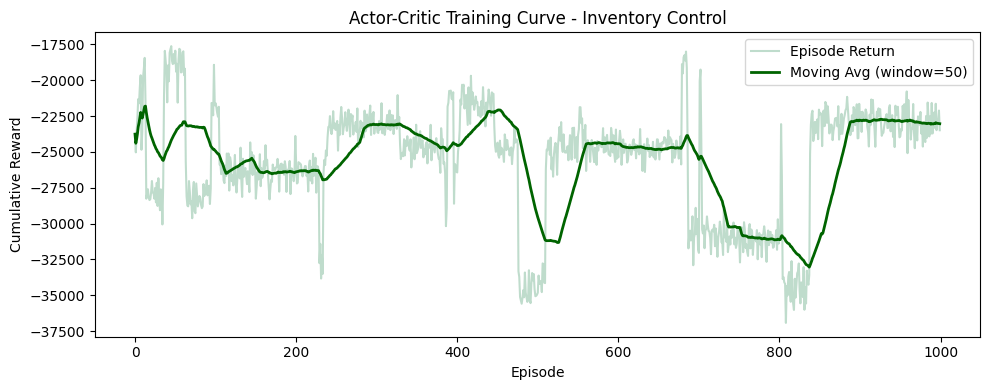

In [7]:
window = 50
moving_avg = [np.mean(returns_list[max(0, i-window):i+1]) for i in range(len(returns_list))]

plt.figure(figsize=(10, 4))
plt.plot(returns_list, alpha=0.3, color='seagreen', label='Episode Return')
plt.plot(moving_avg, color='darkgreen', linewidth=2, label=f'Moving Avg (window={window})')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('Actor-Critic Training Curve - Inventory Control')
plt.legend()
plt.tight_layout()
plt.savefig('ac_learning_curve.png', dpi=150)
plt.show()

## 테스트 (100 에피소드) + 발주 행동 분석

In [8]:
agent.actor.eval()

test_episodes = 100
test_returns = []
order_by_inventory = {I: [] for I in range(env.I_max + 1)}

for episode in range(test_episodes):
    state = env.reset()
    episode_return = 0
    done = False

    while not done:
        _, I = int(state[0]), int(state[1])
        action = agent.choose_greedy_action(state)
        order_by_inventory[I].append(action)

        next_state, reward, done = env.step(action)
        episode_return += reward
        state = next_state

    test_returns.append(episode_return)

print(f"\n[Test] Average Return over {test_episodes} episodes: {np.mean(test_returns):.1f}")
print(f"[Test] Std: {np.std(test_returns):.1f}")


[Test] Average Return over 100 episodes: -22992.2
[Test] Std: 709.6


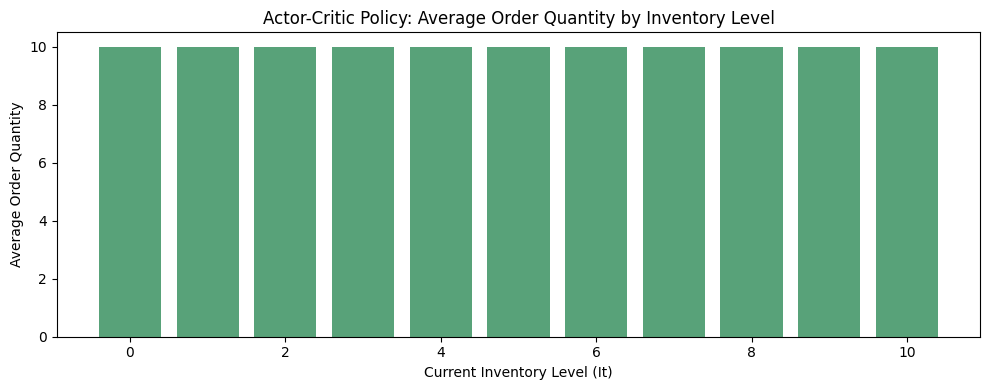


[Policy Analysis] Inventory Level -> Avg Order Quantity
  I= 0 -> avg order = 10.00
  I= 1 -> avg order = 10.00
  I= 2 -> avg order = 10.00
  I= 3 -> avg order = 10.00
  I= 4 -> avg order = 10.00
  I= 5 -> avg order = 10.00
  I= 6 -> avg order = 10.00
  I= 7 -> avg order = 10.00
  I= 8 -> avg order = 10.00
  I= 9 -> avg order = 10.00
  I=10 -> avg order = 10.00


In [9]:
inventory_levels = [I for I in range(env.I_max + 1) if order_by_inventory[I]]
avg_orders = [np.mean(order_by_inventory[I]) for I in inventory_levels]

plt.figure(figsize=(10, 4))
plt.bar(inventory_levels, avg_orders, color='seagreen', alpha=0.8)
plt.xlabel('Current Inventory Level (It)')
plt.ylabel('Average Order Quantity')
plt.title('Actor-Critic Policy: Average Order Quantity by Inventory Level')
plt.tight_layout()
plt.savefig('ac_policy_analysis.png', dpi=150)
plt.show()

print("\n[Policy Analysis] Inventory Level -> Avg Order Quantity")
for I, q in zip(inventory_levels, avg_orders):
    print(f"  I={I:2d} -> avg order = {q:.2f}")